## Homework 9 - due Thursday, April 30 by 4 PM 

Name: Kristen Townsend

In [42]:
import numpy as np
import random
import matplotlib.pyplot as plt
import cmath

### Problem 1: Exercise 10.5, page 472

In [ ]:
# part a

# define the integrand
def f(x):
    return (np.sin(1/(x*(2-x))))**2

# define number of points
N = 10000
# define area
A = 2.0
# define counter k
k = 0.0

# evaluate using MC method
for i in range(N):
    x = 2*random.random()
    y = random.random()
    
    if y < f(x):
        k += 1

# calculate final value
I = k*A / N

# error
p = I/A
error = A + np.sqrt(p*(1-p)/N)

print("I =", I, "+/-", error)

I = 1.4506 +/- 0.008927259601915922


In [18]:
# part b

# define number of points
N = 10000
# starting summation value
s = 0.
# sum of squares
s2 = 0.0

# loop through the summation
for i in range(N):
    x = 2*random.random() # 0 to 2
    # add function value to the summation
    s += f(x)
    s2 += f(x)**2

# mean of f
mean = s/N

# variance of f
var = (s2/N) - mean**2

# calculate integrel estimate
I = 2 * mean

# error
error = 2 * np.sqrt(var/N)


print("I =",I,"+/-",error)


I = 1.4535041803600106 +/- 0.005272425386390393


##### Explanation: 

Solving integral $$I = \int_0^2 \sin^2 \left[ \frac{1}{x(2-x)} \right]dx$$

Area is the rough area of a square/rectangle around where the integration is happening

error found for "hit-or-miss" method
$\text{Error} = \sqrt{\frac{p(1-p)}{N}}$

error found using equations on pg. 471 of the textbook for mean value
$\text{var}\left(f\right) = \left<f^2\right> - \left<f\right>^2$ 

$\text{Error} = 2 \sqrt{\frac{\text{var}\left(f\right)}{N}}$

### Problem 2: Exercise 10.7, page 474

In [ ]:
# define number of points
N = 1000000
# number of dimensions
num_dim = 10

# physical space
R = 1.0
box_vol = 2**num_dim

# starting summation value
s = 0.0

# loop through the summation
for i in range(N):
    x = 2 * np.random.rand(num_dim) - 1 # uniform [0,1]^10
    # add function value to the summation
    if np.sum(x**2) <= R**2:
        s += 1

# calculate final result
V = box_vol * s / N

print("Estimated volume =", V)


Estimated volume = 2.531328


#### Explanation: 

10 dimensional hypersphere


### Problem 3: Exercise 10.10, (a)-(d) only, page 489
This is what we did in lab during Week 12

In [30]:
# part (a)
# define the equation, accepts a 2D array
def E_calc(n_array):
    sum1 = np.sum(n_array[0:-2,:] * n_array[1:-1,:])
    sum2 = np.sum(n_array[:,0:-2] * n_array[:,1:-1])
    return -J * (sum1 + sum2)

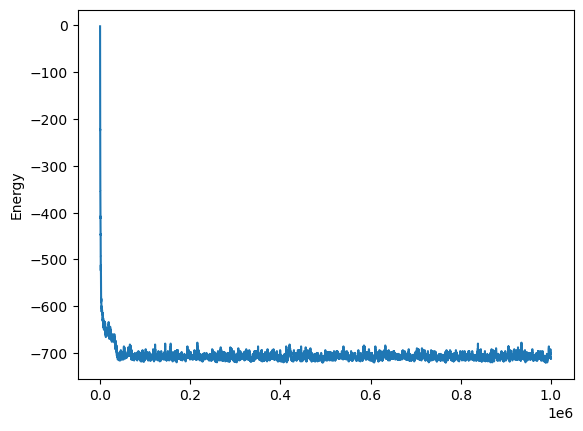

the expectation value is = -706.218372


In [ ]:
# part (b)
# constants
J = 1
T = 1
kB = 1
L = 20 # size of box

# number of repeats
steps = 1000000

# initialize 2D array to store directions (20 x 20)
n_array = np.ones([L,L], int)

# fill the grid
for i in range(L):
    for j in range(L):
        # choose +/- 1
        if random.random() < 0.5:
            n_array[i,j] = 1
        else:
            n_array[i,j] = -1

#print(n_array)

# create blank list of energy values
E_pts = []
M_pts = []
# calculate the starting energy of the system 
E0 = E_calc(n_array)
#(E0)

# MCMC loop
for k in range(steps):
    # choose particle and move using random numbers
    i = random.randrange(L) # choosing coordinates out of L = 20
    j = random.randrange(L) 

    M = 0


    # flip it
    n_array[i][j] *= -1
    # new energy
    dE = E_calc(n_array) - E0
    #print(type(dE))
    
    # apply the metropolis algorithm
    if random.random() < np.exp(-dE/kB): # a probability on if the move is accepted or not
        # accept the move
        E0 += dE
    else:
        # reject the move, undo the flip
        n_array[i][j] *= -1

    # calculate magnetization for part c
    M = np.sum(n_array)
    M_pts.append(M)

    # append the new energy to the list
    E_pts.append(E0)

#print(E_pts)

# graph the results
plt.plot(E_pts)
plt.ylabel("Energy")
plt.show()

# calculate average
print("the expectation value is =", np.sum(E_pts)/steps)

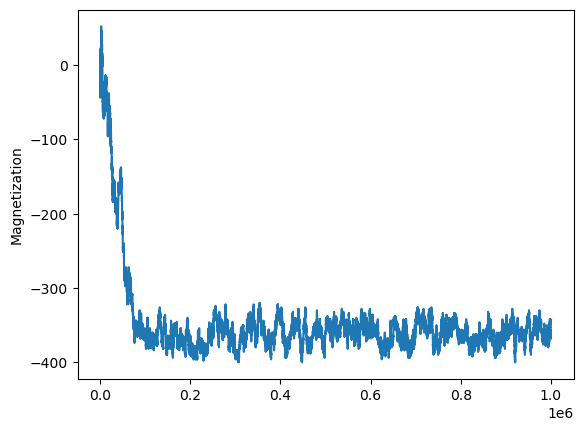

the expectation value is = -347.63474


In [32]:
# part (c)

# repeat from part (b)
# constants
J = 1
T = 1
kB = 1
L = 20 # size of box

# number of repeats
steps = 1000000

# initialize 2D array to store directions (20 x 20)
n_array = np.ones([L,L], int)

# fill the grid
for i in range(L):
    for j in range(L):
        # choose +/- 1
        if random.random() < 0.5:
            n_array[i,j] = 1
        else:
            n_array[i,j] = -1

#print(n_array)

# create blank list of energy values
E_pts = []
M_pts = []
# calculate the starting energy of the system 
E0 = E_calc(n_array)
#(E0)

# MCMC loop
for k in range(steps):
    # choose particle and move using random numbers
    i = random.randrange(L) # choosing coordinates out of L = 20
    j = random.randrange(L) 

    # initialize variable to hod magnitization
    M = 0

    # flip it
    n_array[i][j] *= -1
    # new energy
    dE = E_calc(n_array) - E0
    #print(type(dE))
    
    # apply the metropolis algorithm
    if random.random() < np.exp(-dE/kB): # a probability on if the move is accepted or not
        # accept the move
        E0 += dE
    else:
        # reject the move, undo the flip
        n_array[i][j] *= -1

    # calculate magnetization for part c
    M = np.sum(n_array)
    M_pts.append(M)

    # append the new energy to the list
    E_pts.append(E0)

# graph the results
#plt.plot(np.array(M_pts)/(L*L)) # normalized
plt.plot(M_pts)
plt.ylabel("Magnetization")
plt.show()

# calculate average
print("the expectation value is =", np.sum(M_pts)/steps)

#### part (d)

**(d)** Run your program several times and observe the sign of the magnetization that develops, positive or negative.  Describe what you find and give a brief explanation of what is happening (in markdown).

The magnetization eventually stabilizes at approximately +/- 0.9. The sign varies between runs.

This occurs because the Ising model is symmetric under each spin inversion. Very long systems might eventually flip the sign, but that is unlikely for a system as large as this. 

Each sign is eaqually likely to fall into.


#### Explanation: 

### Problem 4: Exercise 9.12, page 445

In [ ]:
# part a




# making the grid
t2 = 100 # grid squares on a side
L = 1.0 # length of side of box
a = L/M # size of actual grid box

# array of positions
position = np.zeros([t2+1,t2+1], float)
# array of velocities
velocity = np.zeros([t2+1,t2+1], float)
# array of accelerations
accel = np.zeros([t2+1,t2+1], float)





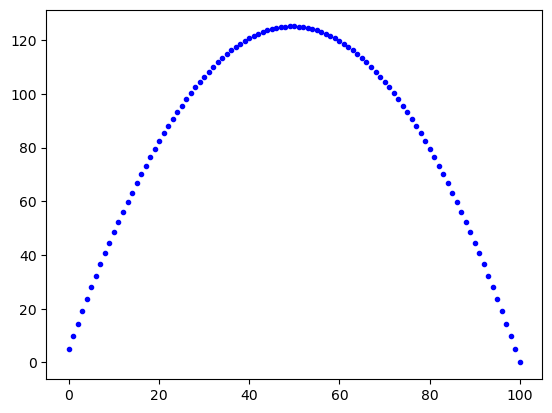

In [83]:
# part b

# constants
m = 1.0 # kg
g = 9.81 #m/s^2

x0 = 0.0
xend = 0.0

n_pts = 100

t1 = 0.0
t2 = 10.0
h = (t2-t1)/n_pts


target = 1e-6 # target accuracy for jacobi method

# array of positions
position = np.zeros(int(n_pts+1), float)
# boundaries
position[0] = x0
position[-1] = xend

# array of new positions
new_position = np.zeros(int(n_pts+1), float)


delta = 1.0

# begin jacobi method loop
while delta > target:
    # calculate the new values of the potential
    for i in range( n_pts):
        new_position[i] = (position[i+1]+ position[i-1] + h**2 * g) / 2
    
    # check maximum difference from the old position
    delta = np.max(np.abs(position - new_position))


    position, new_position = new_position, position

plt.plot(position, "b.")
plt.show()

#### Explanation: 

part a
derive a relaxation-method equation on a time-like grid of points with separation x
eq (5.155) $$f\left(x,t\right) = f''\left(x\right) = \frac{f\left(x+h\right) - 2f\left(x\right) + f\left(x-h\right)}{h^2} = -g $$

rearranged to isolate $f\left(x\right)$

$$f\left(x\right) = \frac{1}{2} \left(f\left(x+h\right) + f\left(x-h\right) + h^2 g \right) $$

### Problem 5: Exercise 7.1, page 306

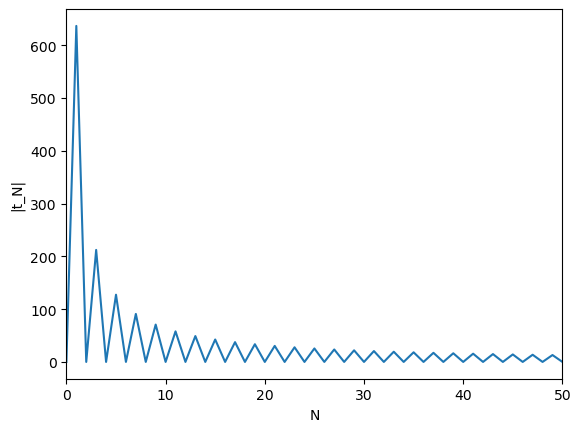

1000.0


In [48]:
# part a

def DFT(y):
    # determine the number of sample points
    N = len(y)
    # create array for fourier coefficients
    c = np.zeros(N//2 + 1, complex)
    # loop through to calculate coefficients
    for k in range(N//2 + 1):
        for n in range(N):
            c[k] += y[n] * cmath.exp(-2j*np.pi*k*n/N)
    return c

# A single cycle of a square-wave with amplitude 1
N = 1000
cycle_vals = np.ones(N)
cycle_vals[N//2:N] = -1


#plt.plot(cycle_vals)

transform = DFT(cycle_vals)
plt.plot(np.abs(transform))
plt.xlabel("N")
plt.ylabel("|t_N|")
plt.xlim(0,50)
plt.show()

# calculating(?) the coefficient
k = 1
N = len(cycle_vals)
period = N/k
print(period)

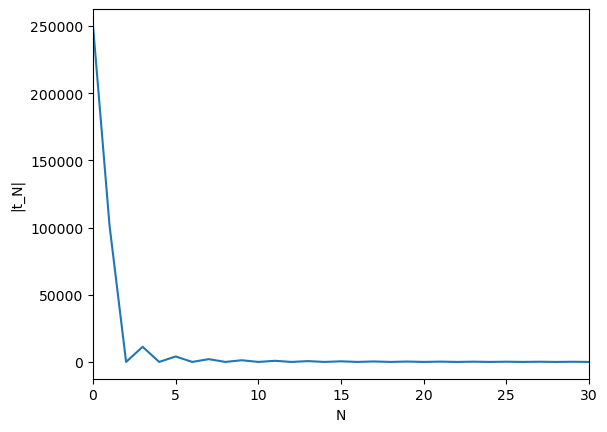

1000.0


In [63]:
# part b
# The sawtooth wave y_n = n
N = 1000
saw_vals = np.zeros(N)

val = 0

for i in range(N):
    if i < N//2:
        val += 1
    else:
        val -= 1
    saw_vals[i] = val



#plt.plot(saw_vals)

saw_trans = DFT(saw_vals)
plt.plot(np.abs(saw_trans))
plt.xlabel("N")
plt.ylabel("|t_N|")
plt.xlim(0,30)
plt.show()

# calculating(?) the coefficient
k = 1
period = N/k
print(period)


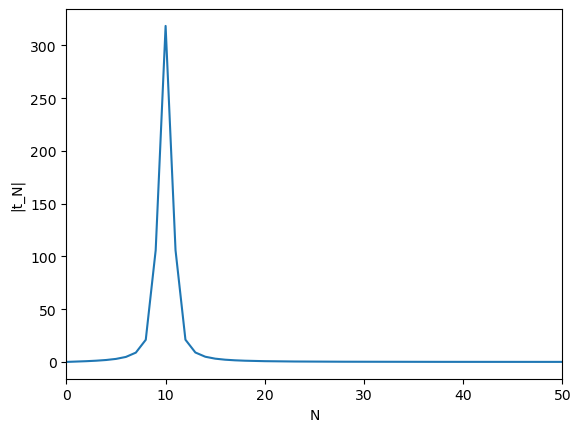

In [66]:
# part c
# The modulated sine wave y_n = sin(pi*n/N)sin(20*pi*n/N)

N = 1000
sine_vals = np.zeros(N)


for i in range(N):
    sine_vals[i] = np.sin(np.pi*i/N)*np.sin(20*np.pi*i/N)

#plt.plot(sine_vals)

sine_trans = DFT(sine_vals)
plt.plot(np.abs(sine_trans))
plt.xlabel("N")
plt.ylabel("|t_N|")
plt.xlim(0,50)
plt.show()


#### Explanation: 

Discrete Fourier transforms
$$ c_k = \sum_{n=0}^{N-1}y_n \exp\left(-i \frac{2\pi kn}{N}\right) $$